# NB05 — Normaliseren en Exporteren

**Input:**
- `data/processed/bt_params.csv` — ruwe BT log-sterkte parameters
- `data/processed/comparison_counts.csv` — vergelijkings- en wintelling per kruispunt

**Output:** `data/output/bt_scores.csv` — definitieve scores voor het CV-model

**Doel:** Normaliseer de ruwe BT-parameters naar [0, 1] en exporteer het scorebestand dat
als trainingslabels dient voor het computer vision model.

**Score-semantiek:**  
Een hogere BT-parameter betekent dat een kruispunt vaker als gevaarlijker werd gekozen.
Na normalisatie geldt: **score = 1 = meest gevaarlijk, score = 0 = minst gevaarlijk**.
Dit sluit aan bij de CV-modelconventie: hoge score = hoog risico.

**Kolommen in de output:**

| Kolom | Inhoud |
|---|---|
| `intersection_id` | Kruispunt-ID (bestandsnaamstam van de foto) |
| `image_path` | Volledig fotopad zoals gebruikt in de survey-app (bv. `/assets/images/182270019.jpeg`) |
| `bt_param_raw` | Ruwe log-sterkte van de ILSR-schatter |
| `bt_score_normalized` | Min-max genormaliseerd naar [0, 1] |
| `n_comparisons` | Aantal keer dat dit kruispunt in een vergelijking verscheen |
| `n_wins` | Aantal keer dat dit kruispunt als gevaarlijker werd gekozen |

## Stap 1 — Data laden

Laad de BT-parameters en de coverage-tellingen uit de vorige notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Notebooks staan in notebooks/, data staat in de bovenliggende map bradley_terry/
BASE_DIR = Path("..")
PROC_DIR = BASE_DIR / "data" / "processed"
OUT_DIR  = BASE_DIR / "data" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

bt_params_df = pd.read_csv(PROC_DIR / "bt_params.csv",        dtype={"intersection_id": str})
counts_df    = pd.read_csv(PROC_DIR / "comparison_counts.csv", dtype={"intersection_id": str})

print(f"BT params rijen:  {len(bt_params_df)}")
print(f"Coverage rijen:   {len(counts_df)}")

BT params rijen:  68
Coverage rijen:   68


## Stap 2 — Min-max normalisatie naar [0, 1]

We schalen de ruwe log-sterkte parameters lineair zodat het minimum 0 wordt en het maximum 1.
De rangorde blijft hierdoor volledig behouden — alleen de schaal verandert.

Hogere score = vaker gekozen als gevaarlijker = hoger risico.

In [2]:
params = bt_params_df["bt_param_ilsr"].values

# Lineaire schaling: (x - min) / (max - min)
scores_norm = (params - params.min()) / (params.max() - params.min())

bt_params_df["bt_score_normalized"] = scores_norm

print(f"Genormaliseerde scores -- min: {scores_norm.min():.4f}, max: {scores_norm.max():.4f}")
print(f"Gemiddelde: {scores_norm.mean():.4f}, Std: {scores_norm.std():.4f}")

Genormaliseerde scores -- min: 0.0000, max: 1.0000
Gemiddelde: 0.5894, Std: 0.2124


## Stap 3 — Samenvoegen met coverage-tellingen

Voeg `n_comparisons` en `n_wins` toe aan de outputtabel. Kruispunten met 0 vergelijkingen
hebben een onbetrouwbare score (die voortkomt uit de regularisatie, niet uit echte data)
en worden expliciet gemarkeerd.

In [3]:
output_df = bt_params_df[["intersection_id", "bt_param_ilsr", "bt_score_normalized"]].rename(
    columns={"bt_param_ilsr": "bt_param_raw"}
)

output_df = output_df.merge(
    counts_df[["intersection_id", "n_comparisons", "n_wins"]],
    on="intersection_id",
    how="left"
)

# Voeg het volledige fotopad toe zoals het in de survey-app wordt gebruikt,
# zodat elke score direct te herleiden is naar de specifieke foto.
output_df["image_path"] = "/assets/images/" + output_df["intersection_id"] + ".jpeg"

# Markeer kruispunten zonder vergelijkingen
no_data = output_df[output_df["n_comparisons"] == 0]
if len(no_data) > 0:
    print(f"WAARSCHUWING: {len(no_data)} kruispunten hebben 0 vergelijkingen (score is onbetrouwbaar):")
    print(no_data["intersection_id"].values)
else:
    print("Alle kruispunten hebben minstens een vergelijking.")

output_df = output_df.sort_values("bt_score_normalized", ascending=False)
output_df.head(10)

Alle kruispunten hebben minstens een vergelijking.


,intersection_id,bt_param_raw,bt_score_normalized,n_comparisons,n_wins,image_path
66,600483010,1.883625,1.000000,36,35,/assets/images/600483010.jpeg
67,600488624,1.250651,0.862026,10,9,/assets/images/600488624.jpeg
58,191269022,1.165261,0.843413,6,6,/assets/images/191269022.jpeg
51,188278029,1.125546,0.834755,4,4,/assets/images/188278029.jpeg
61,192266023,1.099864,0.829158,4,4,/assets/images/192266023.jpeg
62,194264006,0.953093,0.797165,4,4,/assets/images/194264006.jpeg
39,186275043,0.924628,0.790960,4,4,/assets/images/186275043.jpeg
41,186279088,0.924628,0.790960,4,4,/assets/images/186279088.jpeg
38,186275023,0.909198,0.787597,4,4,/assets/images/186275023.jpeg
57,190273120,0.884923,0.782305,6,5,/assets/images/190273120.jpeg


## Stap 4 — Verdeling van eindscores visualiseren

Een histogram van de definitieve scores geeft een laatste indruk van de spreiding.
Bij een goed functionerende survey verwachten we een brede, enigszins bell-vormige verdeling,
niet een piek aan een kant.

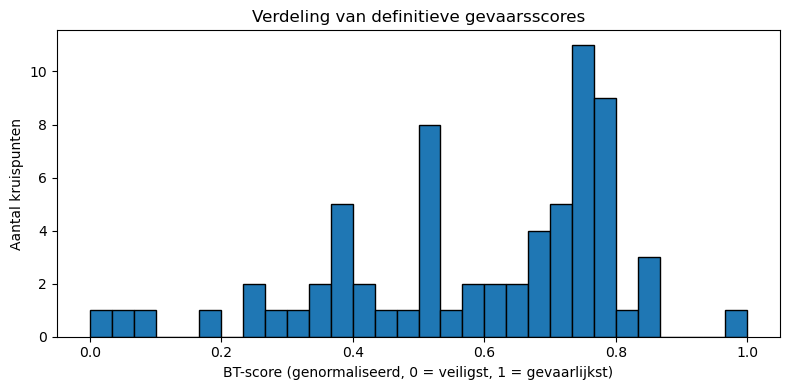

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(output_df["bt_score_normalized"], bins=30, edgecolor="black")
ax.set_xlabel("BT-score (genormaliseerd, 0 = veiligst, 1 = gevaarlijkst)")
ax.set_ylabel("Aantal kruispunten")
ax.set_title("Verdeling van definitieve gevaarsscores")
plt.tight_layout()
plt.savefig(OUT_DIR / "score_distribution.png", dpi=120)
plt.show()

## Stap 5 — Opslaan

Sla het definitieve scorebestand op in `data/output/`. Dit is de interface naar de `cv/`-stap.
De kolomdefinitie en score-semantiek staan gedocumenteerd in `HANDOVER.md`.

In [5]:
out_path = OUT_DIR / "bt_scores.csv"
output_df.to_csv(out_path, index=False)
print(f"Opgeslagen: {len(output_df)} rijen -> {out_path.resolve()}")
print("\nScore-semantiek: 1 = meest gevaarlijk (meest gekozen als hoger risico), 0 = minst gevaarlijk")

Opgeslagen: 68 rijen -> C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\bradley_terry\data\output\bt_scores.csv

Score-semantiek: 1 = meest gevaarlijk (meest gekozen als hoger risico), 0 = minst gevaarlijk
